# TEMPO

short_name = "TEMPO_NO2_L3", version = "V03"

## Create some points

Random global and only over land in 2024.

In [1]:
import pandas as pd
df_points = pd.read_csv(
    "fixtures/points_1000_usa.csv",
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 2024) &
    (df_points["land"] == True)
]
print(len(df))
df.head()

28


,lat,lon,time,land
5,42.919232,-107.118997,2024-02-07 19:04:58,True
22,32.033815,-87.504205,2024-03-12 19:18:24,True
106,44.862977,-110.808178,2024-05-21 15:46:24,True
127,36.649735,-80.935069,2024-04-24 22:48:36,True
138,29.592103,-95.889008,2024-03-30 03:06:23,True


## Create the plan

In [3]:
%%time
import point_collocation as pc
short_name="TEMPO_NO2_L3"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
        "version": "V03"
    },
    time_buffer="1h"
)
plan.summary(n=2)

Plan: 28 points → 30 unique granule(s)
  Points with 0 matches : 17
  Points with >1 matches: 10
  Time buffer: 0 days 01:00:00

First 2 point(s):
  [5] lat=42.9192, lon=-107.1190, time=2024-02-07 19:04:58: 3 match(es)
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.02.07/TEMPO_NO2_L3_V03_20240207T172301Z_S007.nc
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.02.07/TEMPO_NO2_L3_V03_20240207T182301Z_S008.nc
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.02.07/TEMPO_NO2_L3_V03_20240207T192301Z_S009.nc
  [22] lat=32.0338, lon=-87.5042, time=2024-03-12 19:18:24: 2 match(es)
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.03.12/TEMPO_NO2_L3_V03_20240312T174835Z_S009.nc
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.03.12/TEMPO_NO2_L3_V03_20240312T184835Z_S010.nc
CPU times: use

## Look at the variables

We will open a file with datatree and see what groups it has (if any). It does have groups; the latitude, longitude is at the base level: `/` and the product is in `/product`. We want `vertical_column_troposphere` which is the NO2. So we create a profile for TEMPO. We open a dataset with the profile to make sure it looks good.

In [12]:
%%time
tempo = {
    'xarray_open': 'dataset',
    'merge': ['/', '/product'],
}
ds = plan.open_dataset(0, open_method=tempo)
ds

open_method: {'xarray_open': 'dataset', 'merge': ['/', '/product'], 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge_kwargs': {}}
CPU times: user 327 ms, sys: 210 ms, total: 538 ms
Wall time: 4.06 s


<xarray.Dataset> Size: 732MB
Dimensions:                                  (latitude: 2950, longitude: 7750,
                                              time: 1)
Coordinates:
  * latitude                                 (latitude) float32 12kB 14.01 .....
  * longitude                                (longitude) float32 31kB -168.0 ...
  * time                                     (time) datetime64[ns] 8B 2024-01...
Data variables:
    weight                                   (latitude, longitude) float32 91MB dask.array<chunksize=(590, 1550), meta=np.ndarray>
    vertical_column_troposphere              (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 738, 1938), meta=np.ndarray>
    vertical_column_troposphere_uncertainty  (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 738, 1938), meta=np.ndarray>
    vertical_column_stratosphere             (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 738, 1938), meta=np.ndarray>
    main_data_quality_flag                   (time, latitude, longitude) float32 91MB dask.array<chunksize=(1, 984, 2584), meta=np.ndarray>
Attributes: (12/40)
    history:                          2024-08-07T13:18:52Z: L2_regrid -v /tem...
    scan_num:                         1
    time_coverage_start:              2024-01-03T12:52:54Z
    time_coverage_end:                2024-01-03T13:32:40Z
    time_coverage_start_since_epoch:  1388321592.148252
    time_coverage_end_since_epoch:    1388323978.7368417
    ...                               ...
    title:                            TEMPO Level 3 nitrogen dioxide product
    collection_shortname:             TEMPO_NO2_L3
    collection_version:               1
    keywords:                         EARTH SCIENCE>ATMOSPHERE>AIR QUALITY>NI...
    summary:                          Nitrogen dioxide Level 3 files provide ...
    coremetadata:                     \nGROUP                  = INVENTORYMET...

In [13]:
%%time
res = pc.matchup(plan, variables = ["vertical_column_troposphere"], open_method=tempo)

CPU times: user 23 s, sys: 5.12 s, total: 28.1 s
Wall time: 2min 12s


In [15]:
# full res shows more info about matchups, like the granule lat lon
res[['lat', 'lon', 'time', 'vertical_column_troposphere']].dropna(subset=['vertical_column_troposphere']).head()

,lat,lon,time,vertical_column_troposphere
17,44.355987,-95.126999,2024-01-14 16:55:19,3.574082e+14
18,44.355987,-95.126999,2024-01-14 16:55:19,4.644599e+14
19,44.355987,-95.126999,2024-01-14 16:55:19,2.405348e+14
20,42.919232,-107.118997,2024-02-07 19:04:58,8.827827e+14
21,42.919232,-107.118997,2024-02-07 19:04:58,6.472115e+14


## Plot our points with data

In [18]:
ds = plan.open_dataset(2, open_method=tempo)

open_method: {'xarray_open': 'dataset', 'merge': ['/', '/product'], 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge_kwargs': {}}


In [19]:
ds["vertical_column_troposphere"].units

'molecules/cm^2'

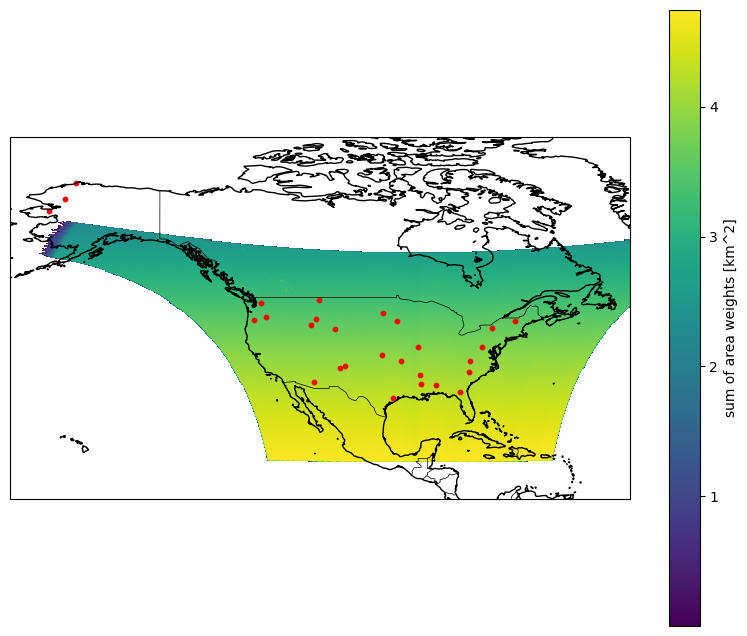

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10,8))

ds_plot = ds.weight.coarsen(latitude=10, longitude=10, boundary="trim").mean()

ax = plt.axes(projection=ccrs.PlateCarree())

# plot xarray field
ds_plot.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    add_colorbar=True
)

# coastlines
ax.coastlines(resolution="50m", linewidth=1)

# optional: borders
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# plot dataframe points
ax.scatter(
    df["lon"],
    df["lat"],
    color="red",
    s=10,
    transform=ccrs.PlateCarree(),
    label="points"
)

# zoom to North America
ax.set_extent([-170, -50, 10, 80], crs=ccrs.PlateCarree())

plt.show()

## MIL3YAEN

In [9]:
import pandas as pd
df_points = pd.read_csv(
    "fixtures/points_1000_usa.csv",
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 2019) &
    (df_points["land"] == True)
]
len(df)

33

In [10]:
import xarray as xr
import earthaccess
results = earthaccess.search_data(
    short_name="MIL3YAEN",
    temporal = (df.time.iloc[0], df.time.iloc[0]),
)
f = earthaccess.open(results[0:1])

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/16)
    Local_granule_id:                 MISR_AM1_CGAS_2019_F15_0032.nc
    Local_version_id:                 MISR_EXEC_VERSION: V6.0.7 MISR_EXEC_NAM...
    PGE_version:                      V6.0.7
    Range_beginning_time:             2018-12-01T00:00:00Z
    Range_ending_time:                2019-11-30T23:59:59Z
    Software_version_information:     Version V6.0.7\nversion info created Tu...
    ...                               ...
    Conventions:                      CF-1.6
    title:                            MISR Level 3 Component Global Aerosol P...
    institution:                      MISR Level 3 Component Global Aerosol P...
    source:                           Aerosol retrievals are obtained from th...
    history:                          2020-01-24T19:28:39 : Initial productio...
    references:                       Data Product Specifications and Algorit...

In [11]:
ds = xr.open_datatree(f[0])
ds

<xarray.DataTree>
Group: /
│   Attributes: (12/16)
│       Local_granule_id:                 MISR_AM1_CGAS_2019_F15_0032.nc
│       Local_version_id:                 MISR_EXEC_VERSION: V6.0.7 MISR_EXEC_NAM...
│       PGE_version:                      V6.0.7
│       Range_beginning_time:             2018-12-01T00:00:00Z
│       Range_ending_time:                2019-11-30T23:59:59Z
│       Software_version_information:     Version V6.0.7\nversion info created Tu...
│       ...                               ...
│       Conventions:                      CF-1.6
│       title:                            MISR Level 3 Component Global Aerosol P...
│       institution:                      MISR Level 3 Component Global Aerosol P...
│       source:                           Aerosol retrievals are obtained from th...
│       history:                          2020-01-24T19:28:39 : Initial productio...
│       references:                       Data Product Specifications and Algorit...
├── Group: /Source_file
│       Dimensions:           (Index: 5297)
│       Coordinates:
│         * Index             (Index) int32 21kB 1 2 3 4 5 ... 5293 5294 5295 5296 5297
│       Data variables:
│           Orbit_Number      (Index) int32 21kB ...
│           Path_Number       (Index) uint8 5kB ...
│           Local_Granule_Id  (Index) object 42kB ...
│           Local_Version_Id  (Index) object 42kB ...
├── Group: /Aerosol_Parameter_Average
│       Dimensions:                                                (Latitude: 360,
│                                                                   Longitude: 720,
│                                                                   Optical_Depth_Range: 9,
│                                                                   Coefficient: 3,
│                                                                   Band: 4,
│                                                                   Algorithm_Type: 3,
│                                                                   Retrieval_Success_Type: 2)
│       Coordinates:
│         * Latitude                                               (Latitude) float64 3kB ...
│         * Longitude                                              (Longitude) float64 6kB ...
│         * Optical_Depth_Range                                    (Optical_Depth_Range) object 72B ...
│         * Coefficient                                            (Coefficient) object 24B ...
│         * Band                                                   (Band) object 32B ...
│         * Algorithm_Type                                         (Algorithm_Type) object 24B ...
│         * Retrieval_Success_Type                                 (Retrieval_Success_Type) object 16B ...
│       Data variables: (12/28)
│           crs                                                    int32 4B ...
│           Absorbing_Optical_Depth                                (Latitude, Longitude, Optical_Depth_Range) float32 9MB ...
│           Absorbing_Optical_Depth_Count                          (Latitude, Longitude, Optical_Depth_Range) float64 19MB ...
│           Absorbing_Optical_Depth_Standard_Deviation             (Latitude, Longitude, Optical_Depth_Range) float32 9MB ...
│           Aerosol_Optical_Depth                                  (Latitude, Longitude, Optical_Depth_Range) float32 9MB ...
│           Aerosol_Optical_Depth_Count                            (Latitude, Longitude, Optical_Depth_Range) float64 19MB ...
│           ...                                                     ...
│           Aerosol_Optical_Depth_Per_Band                         (Latitude, Longitude, Optical_Depth_Range, Band) float32 37MB ...
│           Aerosol_Optical_Depth_Per_Band_Count                   (Latitude, Longitude, Optical_Depth_Range, Band) float64 75MB ...
│           Absorbing_Aerosol_Optical_Depth_Per_Band               (Latitude, Longitude, Optical_Depth_Range, Band) float32 37MB ...
│           Absorbing_Aerosol_Optical

In [ ]:
dt = xr.open_datatree(f[1], decode_timedelta=False, phony_dims='sort')
ds = xr.merge(
    [dt["/Aerosol_Parameter_Average"].ds, dt["/monthly"].ds]
)
ds = ds.set_coords(["grid_lat", "grid_lon"])
ds

## MOP03JM

In [17]:
import xarray as xr
import earthaccess
results = earthaccess.search_data(
    short_name="MOP03JM",
    temporal = ("2024-10-01", "2024-12-31"),
    version = "9"
)
f = earthaccess.open(results[0:1])
f

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

[<File-like object S3FileSystem, asdc-prod-protected/MOPITT/MOP03JM.9/2024.10.01/MOP03JM-202410-L3V95.10.3.he5>]

In [19]:
dt = xr.open_datatree(f[0])
dt

/tmp/ipykernel_6661/1903594676.py:1: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  dt = xr.open_datatree(f[0])


<xarray.DataTree>
Group: /
├── Group: /HDFEOS
│   ├── Group: /HDFEOS/ADDITIONAL
│   │   └── Group: /HDFEOS/ADDITIONAL/FILE_ATTRIBUTES
│   │           Attributes:
│   │               FillValue:    -9999.0
│   │               StartTime:    1001894415.832
│   │               StopTime:     1004570188.0299994
│   │               institution:  MOPITT at ACOM of NCAR
│   │               title:        MOPITT Level 3 Monthly File
│   └── Group: /HDFEOS/GRIDS
│       └── Group: /HDFEOS/GRIDS/MOP03
│           │   Dimensions:  (NTWO: 2, Prs: 9, Prs1: 10, Prs2: 10, XDim: 360, YDim: 180)
│           │   Coordinates:
│           │     * NTWO     (NTWO) int32 8B 0 1
│           │     * Prs      (Prs) float32 36B 900.0 800.0 700.0 600.0 ... 300.0 200.0 100.0
│           │     * Prs1     (Prs1) float32 40B 1e+03 900.0 800.0 700.0 ... 300.0 200.0 100.0
│           │     * Prs2     (Prs2) float32 40B 1e+03 900.0 800.0 700.0 ... 300.0 200.0 100.0
│           │     * XDim     (XDim) float64 3kB -180.0 -179.0 -178.0 ... 177.0 178.0 179.0
│           │     * YDim     (YDim) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
│           └── Group: /HDFEOS/GRIDS/MOP03/Data Fields
│                   Dimensions:                                            (XDim: 360, YDim: 180,
│                                                                           Prs: 9, Prs1: 10,
│                                                                           Prs2: 10, NTWO: 2)
│                   Data variables: (12/80)
│                       APrioriCOMixingRatioProfileDay                     (XDim, YDim, Prs) float32 2MB ...
│                       APrioriCOMixingRatioProfileNight                   (XDim, YDim, Prs) float32 2MB ...
│                       APrioriCOSurfaceMixingRatioDay                     (XDim, YDim) float32 259kB ...
│                       APrioriCOSurfaceMixingRatioNight                   (XDim, YDim) float32 259kB ...
│                       APrioriCOTotalColumnDay                            (XDim, YDim) float32 259kB ...
│                       APrioriCOTotalColumnNight                          (XDim, YDim) float32 259kB ...
│                       ...                                                 ...
│                       SurfacePressureDay                                 (XDim, YDim) float32 259kB ...
│                       SurfacePressureNight                               (XDim, YDim) float32 259kB ...
│                       TotalColumnAveragingKernelDay                      (XDim, YDim, Prs1) float32 3MB ...
│                       TotalColumnAveragingKernelNight                    (XDim, YDim, Prs1) float32 3MB ...
│                       WaterVaporColumnDay                                (XDim, YDim) float32 259kB ...
│                       WaterVaporColumnNight                              (XDim, YDim) float32 259kB ...
└── Group: /HDFEOS INFORMATION
        Dimensions:           (phony_dim_0: 1)
        Dimensions without coordinates: phony_dim_0
        Data variables:
            StructMetadata.0  |S32000 32kB ...
            coremetadata.0    (phony_dim_0) |S7571 8kB ...
        Attributes:
            HDFEOSVersion:  HDFEOS_5.1.16